## Reproduciable Plots and Tables

Figure 4, 5, 6, 7
Table 1 4, 5, 6, 7, 8

Not yet:

FIgure 6
Figure 8 9 10

# Device

In [7]:
import math
import pandas as pd

# --------------------------------------------------
# Config
# --------------------------------------------------
CSV_PATH = "/home/skataoka26/COSC_498/devices/results/cache_sweep/uniform_370/nvsim_uniform_370.csv"
FREQ_GHZ = 2.2
CAPS_TO_SHOW = [16, 32, 128]

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def ns_to_cycles(ns, freq_ghz=FREQ_GHZ):
    return math.ceil(ns * freq_ghz)

def infer_tech(path):
    s = str(path)
    if "/SRAM/" in s:
        return "SRAM"
    if "/MRAM/" in s:
        return "MRAM"
    return "UNKNOWN"

# --------------------------------------------------
# Load
# --------------------------------------------------
df = pd.read_csv(CSV_PATH)
df["technology"] = df["stdout_path"].apply(infer_tech)

# keep only the capacities you want
df = df[df["cap_mb"].isin(CAPS_TO_SHOW)].copy()

# --------------------------------------------------
# Convert fields for display
# --------------------------------------------------
df["read_cycles"] = df["lat_hit_ns"].apply(ns_to_cycles)
df["write_cycles"] = df["lat_write_ns"].apply(ns_to_cycles)

# --------------------------------------------------
# Pick one row per (capacity, tech, node)
# If multiple optimization-target rows exist, choose the one with
# minimum effective latency at f_w = 0.7 just to make the table unique.
# --------------------------------------------------
F_W = 0.7
df["L_eff"] = (1 - F_W) * df["lat_hit_ns"] + F_W * df["lat_write_ns"]

idx = df.groupby(["cap_mb", "technology", "node_nm"])["L_eff"].idxmin()
show = df.loc[idx].copy()

show = show.sort_values(
    by=["cap_mb", "technology", "node_nm"],
    key=lambda s: s.map({"SRAM": 0, "MRAM": 1}) if s.name == "technology" else s
)

# --------------------------------------------------
# Print like the example
# --------------------------------------------------
header = (
    f"{'MB':>4}  "
    f"{'Tech':<6}  "
    f"{'Node':<8}  "
    f"{'Read Lat.':>10}  "
    f"{'Write Lat.':>11}  "
    f"{'Leak.':>8}  "
    f"{'Area':>8}"
)

subheader = (
    f"{'':>4}  "
    f"{'':<6}  "
    f"{'(nm)':<8}  "
    f"{'(cycles)':>10}  "
    f"{'(cycles)':>11}  "
    f"{'(mW)':>8}  "
    f"{'(mm^2)':>8}"
)

print(header)
print(subheader)
print("-" * len(header))

prev_cap = None
for _, r in show.iterrows():
    cap = int(r["cap_mb"])
    if prev_cap is not None and cap != prev_cap:
        print()

    print(
        f"{cap:>4}  "
        f"{r['technology']:<6}  "
        f"{str(int(r['node_nm'])) + ' nm':<8}  "
        f"{int(r['read_cycles']):>10}  "
        f"{int(r['write_cycles']):>11}  "
        f"{float(r['leakage_mW']):>8.1f}  "
        f"{float(r['area_total_mm2']):>8.2f}"
    )
    prev_cap = cap

  MB  Tech    Node       Read Lat.   Write Lat.     Leak.      Area
              (nm)        (cycles)     (cycles)      (mW)    (mm^2)
-------------------------------------------------------------------
  16  SRAM    7 nm               6            4     193.0      4.54
  16  SRAM    14 nm             13            7     170.9     10.25
  16  SRAM    22 nm             20           11     115.9     15.18
  16  SRAM    32 nm             16            9      99.4     26.87
  16  MRAM    14 nm              5           47     107.0      3.19
  16  MRAM    32 nm             13           28      53.8     11.77

  32  SRAM    7 nm              11            6     420.1      8.95
  32  SRAM    14 nm             24           12     330.4     19.99
  32  SRAM    22 nm             35           18     230.8     29.41
  32  SRAM    32 nm             26           14     129.1     48.67
  32  MRAM    14 nm              8           48     104.6      5.53
  32  MRAM    32 nm             17           30

# Workload Characterization

## tab: 

In [ ]:
#!/usr/bin/env python3
import pandas as pd

CSV = "/home/skataoka26/COSC_498/miniMXE/repro/agg/workload.csv"

NAME_MAP = {
    "505.mcf_r": "mcf",
    "523.xalancbmk_r": "xalancbmk",
    "500.perlbench_r": "perlbench",
    "520.omnetpp_r": "omnetpp",
    "502.gcc_r": "gcc",
    "557.xz_r": "xz",
    "531.deepsjeng_r": "deepsjeng",
    "541.leela_r": "leela",
    "649.fotonik3d_s": "fotonik3d",
    "648.exchange2_s": "exchange2",
}

T4_ORDER = [
    "mcf", "xalancbmk", "perlbench", "omnetpp", "gcc",
    "xz", "deepsjeng", "leela", "fotonik3d", "exchange2"
]

T5_ORDER = ["mcf", "xalancbmk", "deepsjeng", "leela"]

df = pd.read_csv(CSV)

df["short"] = df["workload"].map(NAME_MAP)

# -----------------------------
# Table 4: 16 MB all-MRAM
# -----------------------------
t4 = df[
    (df["n_tag"] == "n1") &
    (df["size_mb"] == 16) &
    (df["config"] == "MRAM14") &
    (df["short"].notna())
].copy()

t4["Write % of Hits"] = (
    t4["l3_write_hits"] / (t4["l3_read_hits"] + t4["l3_write_hits"])
).fillna(0)

t4["Workload"] = pd.Categorical(t4["short"], categories=T4_ORDER, ordered=True)
t4 = t4.sort_values("Workload")

t4_out = pd.DataFrame({
    "Workload": t4["short"],
    "inst/ns": t4["throughput_inst_ns"].map(lambda x: f"{x:.2f}"),
    "L3 Read Hits": t4["l3_read_hits"].map(lambda x: f"{int(round(x)):,}"),
    "L3 Write Hits": t4["l3_write_hits"].map(lambda x: f"{int(round(x)):,}"),
    "Miss Rate": t4["l3_miss_rate"].map(lambda x: f"{100*x:.1f}%"),
    "Write % of Hits": t4["Write % of Hits"].map(lambda x: f"{100*x:.1f}%"),
})

print("\nTable 4: Measured workload behavior at the 16 MB all-MRAM design point\n")
print(t4_out.to_string(index=False))

# -----------------------------
# Table 5: 16MB SRAM7 vs 128MB MRAM14
# -----------------------------
base = df[
    (df["n_tag"] == "n1") &
    (df["size_mb"] == 16) &
    (df["config"] == "SRAM7") &
    (df["short"].isin(T5_ORDER))
][["short", "makespan_s", "long_lat_frac", "mem_cpi_frac"]].copy()

base = base.rename(columns={
    "makespan_s": "Runtime_16MB",
    "long_lat_frac": "LongLat_16MB",
    "mem_cpi_frac": "MemCPI_16MB",
})

target = df[
    (df["n_tag"] == "n1") &
    (df["size_mb"] == 128) &
    (df["config"] == "MRAM14") &
    (df["short"].isin(T5_ORDER))
][["short", "makespan_s", "long_lat_frac", "mem_cpi_frac"]].copy()

target = target.rename(columns={
    "makespan_s": "Runtime_128MB",
    "long_lat_frac": "LongLat_128MB",
    "mem_cpi_frac": "MemCPI_128MB",
})

t5 = base.merge(target, on="short", how="inner")
t5["Workload"] = pd.Categorical(t5["short"], categories=T5_ORDER, ordered=True)
t5 = t5.sort_values("Workload")

t5_out = pd.DataFrame({
    "Workload": t5["short"],
    "Runtime (ms) 16MB": t5["Runtime_16MB"].map(lambda x: f"{x*1000:.1f}"),
    "Runtime (ms) 128MB": t5["Runtime_128MB"].map(lambda x: f"{x*1000:.1f}"),
    "Long-lat Stall 16MB": t5["LongLat_16MB"].map(lambda x: f"{100*x:.1f}%"),
    "Long-lat Stall 128MB": t5["LongLat_128MB"].map(lambda x: f"{100*x:.1f}%"),
    "Mem CPI Frac 16MB": t5["MemCPI_16MB"].map(lambda x: f"{100*x:.1f}%"),
    "Mem CPI Frac 128MB": t5["MemCPI_128MB"].map(lambda x: f"{100*x:.1f}%"),
})

print("\nTable 5: Representative workload dependence when moving from 16 MB SRAM7 to 128 MB MRAM14\n")
print(t5_out.to_string(index=False))

# Capacity scaling and HCA

Reading /home/skataoka26/COSC_498/miniMXE/repro/agg/hca.csv...
Read 332 rows.
After filtering: 332 rows

All techs:  ['mram14', 'mram32', 'sram14', 'sram14_mram14', 'sram32', 'sram7']
All sizes:  [16, 32, 128]

Crossnode: 150 rows
Sizes: [16, 32, 128]
HCA: 134 rows
Hybrid: 194 rows

=== Crossnode Bar ===


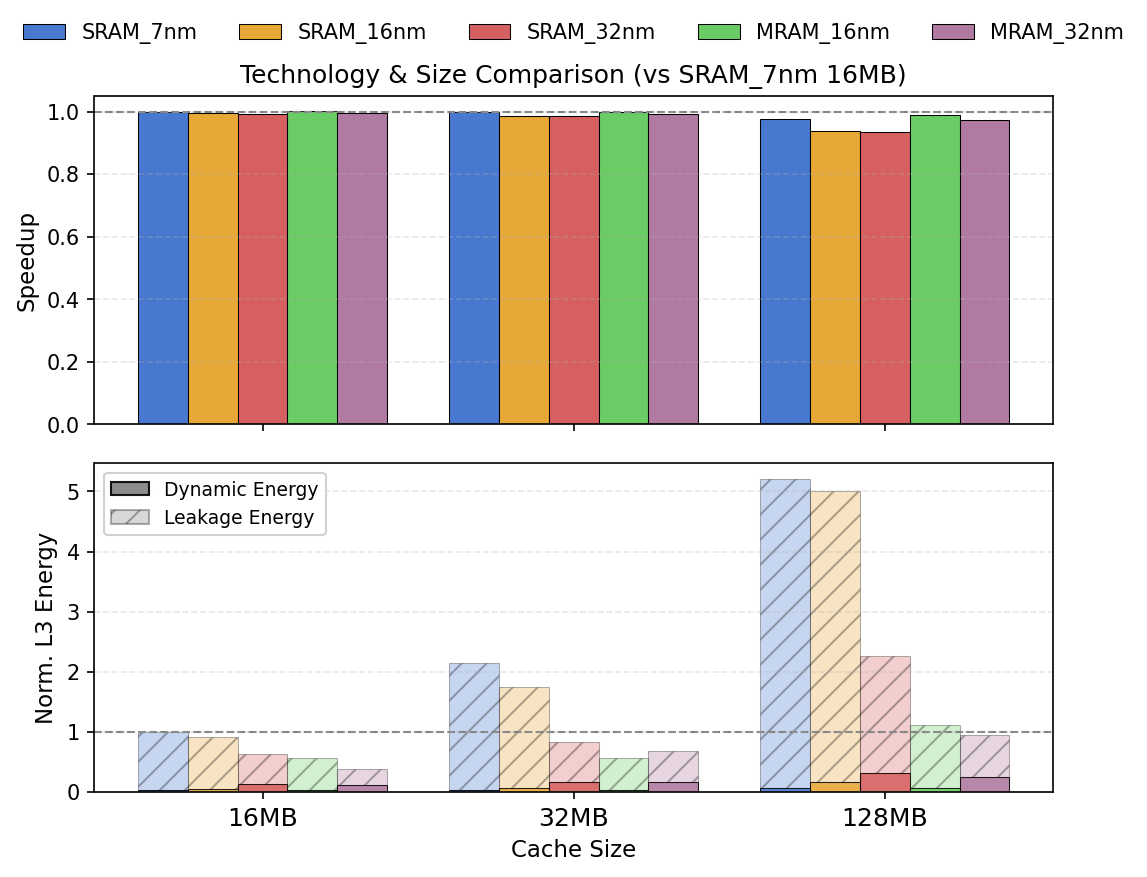


=== Static Scatter ===


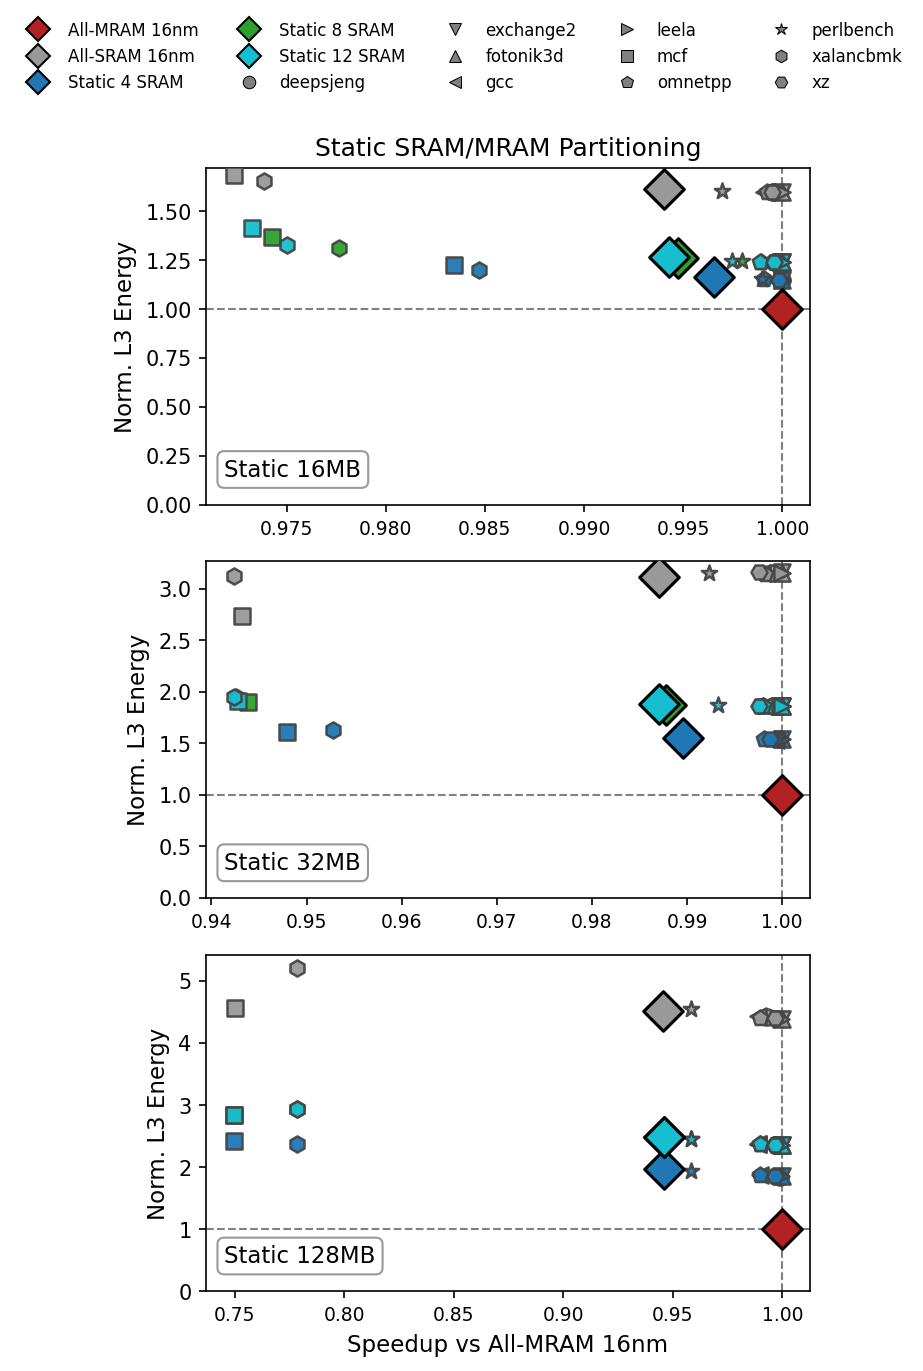


=== Read-Only Latency Sweep (84 rows) ===
    mcf 16MB 2.0x: speedup=0.9940
    mcf 32MB 2.0x: speedup=0.9737
    mcf 128MB 2.0x: speedup=0.8245
    mcf 16MB 3.0x: speedup=1.0037
    mcf 32MB 3.0x: speedup=0.9998
    mcf 128MB 3.0x: speedup=0.9211
    mcf 16MB 4.0x: speedup=1.0126
    mcf 32MB 4.0x: speedup=1.0257
    mcf 128MB 4.0x: speedup=1.0217
    mcf 16MB 5.0x: speedup=1.0223
    mcf 32MB 5.0x: speedup=1.0554
    mcf 128MB 5.0x: speedup=1.1243
    omnetpp 16MB 2.0x: speedup=0.9998
    omnetpp 32MB 2.0x: speedup=0.9992
    omnetpp 128MB 2.0x: speedup=0.9934
    omnetpp 16MB 3.0x: speedup=1.0002
    omnetpp 32MB 3.0x: speedup=1.0000
    omnetpp 128MB 3.0x: speedup=0.9970
    omnetpp 16MB 4.0x: speedup=1.0006
    omnetpp 32MB 4.0x: speedup=1.0009
    omnetpp 128MB 4.0x: speedup=1.0008
    omnetpp 16MB 5.0x: speedup=1.0010
    omnetpp 32MB 5.0x: speedup=1.0019
    omnetpp 128MB 5.0x: speedup=1.0048


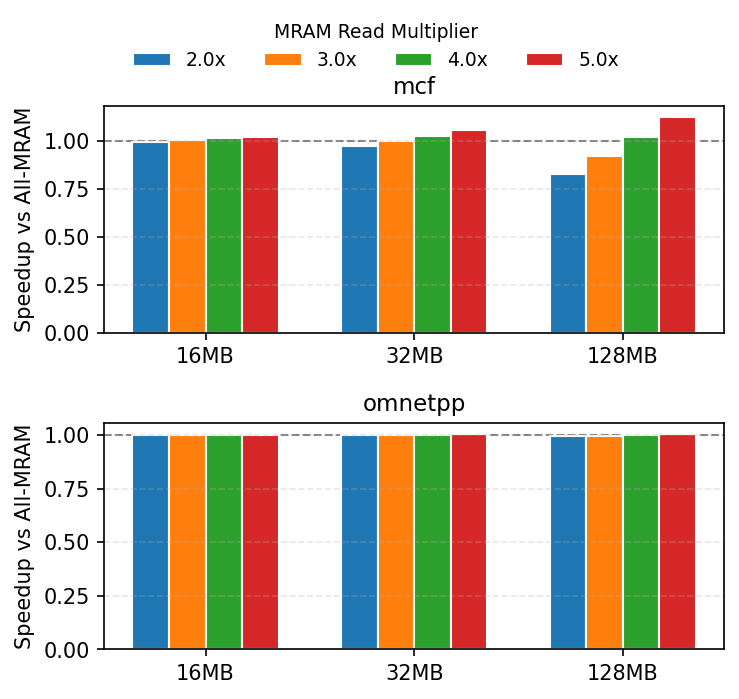


Done!


In [17]:
import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
import yaml

BASE_DIR = Path("~/COSC_498/miniMXE").expanduser()
ALL_CSV    = Path("~/COSC_498/miniMXE/repro/agg/hca.csv").expanduser()

ASSOC = 16

DEVICE_DIR = BASE_DIR / "mx3" / "config" / "devices" / "sunnycove"

def load_nvsim_params(device_dir):
    def _read_yaml(fname):
        with open(device_dir / fname, "r") as f:
            raw = yaml.safe_load(f) or {}
        out = {}
        for size_mb, vals in raw.items():
            out[str(size_mb)] = {
                "r_pj": float(vals.get("r_pj", 0.0)),
                "w_pj": float(vals.get("w_pj", 0.0)),
                "leak_mw": float(vals.get("leak_mw", 0.0)),
            }
        return out

    sram7  = _read_yaml("sram7.yaml")
    sram14 = _read_yaml("sram14.yaml")
    sram32 = _read_yaml("sram32.yaml")
    mram14 = _read_yaml("mram14.yaml")
    mram32 = _read_yaml("mram32.yaml")

    params = {}

    # Pure SRAM techs
    params["sram7"] = {
        sz: {
            "SRAM_R_pJ": v["r_pj"],
            "SRAM_W_pJ": v["w_pj"],
            "SRAM_LEAK_mW": v["leak_mw"],
            "MRAM_R_pJ": 0.0,
            "MRAM_W_pJ": 0.0,
            "MRAM_LEAK_mW": 0.0,
        }
        for sz, v in sram7.items()
    }

    params["sram14"] = {
        sz: {
            "SRAM_R_pJ": v["r_pj"],
            "SRAM_W_pJ": v["w_pj"],
            "SRAM_LEAK_mW": v["leak_mw"],
            "MRAM_R_pJ": 0.0,
            "MRAM_W_pJ": 0.0,
            "MRAM_LEAK_mW": 0.0,
        }
        for sz, v in sram14.items()
    }

    params["sram32"] = {
        sz: {
            "SRAM_R_pJ": v["r_pj"],
            "SRAM_W_pJ": v["w_pj"],
            "SRAM_LEAK_mW": v["leak_mw"],
            "MRAM_R_pJ": 0.0,
            "MRAM_W_pJ": 0.0,
            "MRAM_LEAK_mW": 0.0,
        }
        for sz, v in sram32.items()
    }

    # Pure MRAM techs, but keep SRAM side populated to match old run.yaml logic
    params["mram14"] = {}
    for sz in sorted(set(sram14.keys()) | set(mram14.keys()), key=lambda x: int(x)):
        sv = sram14.get(sz, {"r_pj": 0.0, "w_pj": 0.0, "leak_mw": 0.0})
        mv = mram14.get(sz, {"r_pj": 0.0, "w_pj": 0.0, "leak_mw": 0.0})
        params["mram14"][sz] = {
            "SRAM_R_pJ": sv["r_pj"],
            "SRAM_W_pJ": sv["w_pj"],
            "SRAM_LEAK_mW": sv["leak_mw"],
            "MRAM_R_pJ": mv["r_pj"],
            "MRAM_W_pJ": mv["w_pj"],
            "MRAM_LEAK_mW": mv["leak_mw"],
        }

    params["mram32"] = {}
    for sz in sorted(set(sram32.keys()) | set(mram32.keys()), key=lambda x: int(x)):
        sv = sram32.get(sz, {"r_pj": 0.0, "w_pj": 0.0, "leak_mw": 0.0})
        mv = mram32.get(sz, {"r_pj": 0.0, "w_pj": 0.0, "leak_mw": 0.0})
        params["mram32"][sz] = {
            "SRAM_R_pJ": sv["r_pj"],
            "SRAM_W_pJ": sv["w_pj"],
            "SRAM_LEAK_mW": sv["leak_mw"],
            "MRAM_R_pJ": mv["r_pj"],
            "MRAM_W_pJ": mv["w_pj"],
            "MRAM_LEAK_mW": mv["leak_mw"],
        }

    # Explicit hybrid key used by your HCA rows
    params["sram14_mram14"] = dict(params["mram14"])

    return params

NVSIM_PARAMS = load_nvsim_params(DEVICE_DIR)

# (display_name, tech_value, variant_substring)
DESIGNS = [
    ("SRAM_7nm",  "sram7",  "baseline_sram_only"),
    ("SRAM_16nm", "sram14", "baseline_sram_only"),
    ("SRAM_32nm", "sram32", "baseline_sram_only"),
    ("MRAM_16nm", "mram14", "baseline_mram_only"),
    ("MRAM_32nm", "mram32", "baseline_mram_only"),
]

_STATIC_SCENARIOS = [
    ("All-MRAM 16nm",   "mram14", "baseline_mram_only"),
    ("All-SRAM 16nm",   "sram14", "baseline_sram_only"),
    ("Static 4 SRAM",   "sram14_mram14", "noparity_s4_fillmram_sram14_mram14"),
    ("Static 8 SRAM",   "sram14_mram14", "noparity_s8_fillmram_sram14_mram14"),
    ("Static 12 SRAM",  "sram14_mram14", "noparity_s12_fillmram_sram14_mram14"),
]

_COMBINED_COLORS = {
    "All-MRAM 16nm":       "#B22222",
    "All-SRAM 16nm":       "#999999",
    "Static 4 SRAM":       "#1f77b4",
    "Static 8 SRAM":       "#2ca02c",
    "Static 12 SRAM":      "#17becf",
}

_BENCH_MARKERS = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 9, "ytick.labelsize": 10,
    "legend.fontsize": 10, "figure.dpi": 150,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

# =============================================================================
# Helpers
# =============================================================================
def gmean(xs):
    xs = np.asarray(list(xs), dtype=float)
    xs = xs[np.isfinite(xs) & (xs > 0)]
    return float(np.exp(np.mean(np.log(xs)))) if xs.size else float("nan")

def _short_bench(name):
    parts = name.split("+")
    shortened = []
    for p in parts:
        s = re.sub(r'^\d+_', '', p)
        s = re.sub(r'_(r|s)$', '', s)
        shortened.append(s)
    return "+".join(shortened)

def compute_w_sram(df_in):
    v = df_in["variant"].fillna("").astype(str)
    w = np.full(len(df_in), np.nan, dtype=float)
    w[v.str.contains("baseline_sram_only", na=False).values] = 1.0
    w[v.str.contains("baseline_mram_only", na=False).values] = 0.0
    sw = pd.to_numeric(df_in.get("sram_ways", np.nan), errors="coerce").values
    ft = df_in.get("fill_to", "").fillna("").astype(str).str.lower().values
    for i in range(len(w)):
        if np.isfinite(w[i]): continue
        try: frac = float(sw[i]) / ASSOC
        except: frac = 0.5
        if ft[i] == "sram": frac = max(frac, 0.6)
        if ft[i] == "mram": frac = min(frac, 0.4)
        w[i] = np.clip(frac, 0.0, 1.0)
    return w

# =============================================================================
# Data Loading
# =============================================================================
def load_all():
    print(f"Reading {ALL_CSV}...")
    df = pd.read_csv(ALL_CSV)
    print(f"Read {len(df)} rows.")

    df.rename(columns={
        "workload": "bench", "device": "tech", "instructions": "insn",
        "l3_rh_sram": "read_hits_sram", "l3_rh_mram": "read_hits_mram",
        "l3_wh_sram": "write_hits_sram", "l3_wh_mram": "write_hits_mram",
    }, inplace=True)

    df["size_mb"] = (
        df["capacity"].astype(str)
        .str.replace(r"^sz", "", regex=True)
        .str.replace(r"M$", "", regex=True)
    )
    df["size_mb"] = pd.to_numeric(df["size_mb"], errors="coerce")
    df["roi_time_s"] = df["elapsed_ns"] / 1e9

    def _build_rw_tag(row):
        ls = row.get("lat_scale")
        dev = str(row.get("tech", ""))
        if pd.isna(ls) or str(ls).strip() == "":
            m_dev = re.search(r"_rd(\d+)x", dev)
            if m_dev: return f"r{m_dev.group(1)}x"
            return ""
        m = re.search(r"(r\d+x_w\d+x)", dev)
        if m: return m.group(1)
        m2 = re.search(r"rd(\d+)x", dev)
        if m2: return f"r{m2.group(1)}x"
        return str(ls)
    df["rw_tag"] = df.apply(_build_rw_tag, axis=1)

    df["tech"] = (df["tech"].astype(str)
                  .str.replace(r"_r\d+x_w\d+x$", "", regex=True)
                  .str.replace(r"_rd\d+x$", "", regex=True))

    def _synth_variant(row):
        hca  = str(row.get("hca", "")).strip().lower()
        tech = str(row.get("tech", ""))
        wp   = str(row.get("way_policy", "")).strip().lower() if pd.notna(row.get("way_policy")) else ""
        sm   = str(row.get("static_or_migration", "")).strip().lower() if pd.notna(row.get("static_or_migration")) else ""
        rf   = str(row.get("restricted_fill", "")).strip().lower() if pd.notna(row.get("restricted_fill")) else ""
        s_val = row.get("s")
        p_val = row.get("p")
        c_val = row.get("c")
        if hca != "yes":
            if "mram" in tech and "sram" not in tech:   return "baseline_mram_only"
            elif "sram" in tech and "mram" not in tech: return "baseline_sram_only"
            elif "mram" in tech:                        return "baseline_mram_only"
            return "baseline"
        parts = []
        if wp: parts.append(wp)
        if pd.notna(s_val) and str(s_val).strip() != "":
            parts.append(f"s{int(float(s_val))}")
        parts.append("fillmram")
        if rf == "yes": parts.append("rf")
        if sm == "migration":
            if pd.notna(p_val) and str(p_val).strip() != "": parts.append(f"p{int(float(p_val))}")
            if pd.notna(c_val) and str(c_val).strip() != "": parts.append(f"c{int(float(c_val))}")
        parts.append(tech)
        return "_".join(parts)
    df["variant"] = df.apply(_synth_variant, axis=1)

    df["read_hits"]  = df["read_hits_sram"].fillna(0) + df["read_hits_mram"].fillna(0)
    df["write_hits"] = df["write_hits_sram"].fillna(0) + df["write_hits_mram"].fillna(0)
    df["misses"]     = df["dram_reads"].fillna(0) + df["dram_writes"].fillna(0)

    def _sram_ways(row):
        v = str(row["variant"])
        if "baseline_sram_only" in v: return ASSOC
        if "baseline_mram_only" in v: return 0
        s = row.get("s")
        if pd.notna(s) and str(s).strip() != "":
            try: return int(float(s))
            except: pass
        return 0
    df["sram_ways"] = df.apply(_sram_ways, axis=1).astype(int)
    df["fill_to"] = df["variant"].apply(
        lambda v: "sram" if "baseline_sram_only" in v else "mram")
    df["fill_to_l"] = df["fill_to"].str.lower()

    sm_col = df.get("static_or_migration")
    df["migration_enabled"] = (
        sm_col.fillna("").astype(str).str.strip().str.lower() == "migration"
    ) if sm_col is not None else False

    nums = ["roi_time_s", "read_hits", "write_hits", "misses", "size_mb",
            "sram_ways", "read_hits_sram", "read_hits_mram",
            "write_hits_sram", "write_hits_mram", "insn"]
    for c in nums:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    df["variant"] = df["variant"].astype(str)
    df["tech"]    = df["tech"].astype(str)
    df["bench"]   = df["bench"].astype(str)

    ok = df["roi_time_s"].fillna(0) > 0
    exclude_mask = (
        df["bench"].str.contains("lbm", case=False) |
        df["bench"].str.contains("619", case=False) |
        df["bench"].str.contains("wrf", case=False) |
        df["bench"].str.contains("621", case=False)
    )
    df = df[ok & (~exclude_mask)].copy()
    print(f"After filtering: {len(df)} rows")
    return df

# =============================================================================
# Energy Calculation
# =============================================================================
def calc_energy(df):
    df = df.copy()
    df["w_sram"] = compute_w_sram(df)
    n = len(df)
    dyn_J = np.full(n, np.nan)
    leak_J = np.full(n, np.nan)

    nvsim_tech_map = {"sram14": "mram14", "sram14_mram14": "mram14"}

    for i in range(n):
        tech = df.iloc[i]["tech"]
        lookup_tech = nvsim_tech_map.get(tech, tech)
        size_mb = int(df.iloc[i]["size_mb"]) if pd.notna(df.iloc[i]["size_mb"]) else None
        if size_mb is None:
            continue

        p = NVSIM_PARAMS.get(lookup_tech, {}).get(str(size_mb))
        if p is None:
            continue

        frac = df["w_sram"].iloc[i]
        rh_s = df.iloc[i].get("read_hits_sram", 0) or 0
        rh_m = df.iloc[i].get("read_hits_mram", 0) or 0
        wh_s = df.iloc[i].get("write_hits_sram", 0) or 0
        wh_m = df.iloc[i].get("write_hits_mram", 0) or 0

        if (rh_s + rh_m + wh_s + wh_m) > 0:
            dyn_pJ = (
                rh_s * p["SRAM_R_pJ"] + rh_m * p.get("MRAM_R_pJ", 0) +
                wh_s * p["SRAM_W_pJ"] + wh_m * p.get("MRAM_W_pJ", 0)
            )
        else:
            r = df.iloc[i].get("read_hits", 0) or 0
            w = df.iloc[i].get("write_hits", 0) or 0
            dyn_pJ = (
                r * (frac * p["SRAM_R_pJ"] + (1 - frac) * p.get("MRAM_R_pJ", 0)) +
                w * (frac * p["SRAM_W_pJ"] + (1 - frac) * p.get("MRAM_W_pJ", 0))
            )

        misses = df.iloc[i].get("misses", 0) or 0
        fill_to = df.iloc[i].get("fill_to_l", "mram")
        fill_w = p["SRAM_W_pJ"] if fill_to == "sram" else p.get("MRAM_W_pJ", 0)
        dyn_pJ += misses * fill_w

        dyn_J[i] = dyn_pJ * 1e-12

        leak_mW = frac * p["SRAM_LEAK_mW"] + (1 - frac) * p.get("MRAM_LEAK_mW", 0)
        t = df.iloc[i]["roi_time_s"]
        if pd.notna(t) and t > 0:
            leak_J[i] = (leak_mW * 1e-3) * t

    df["E_dyn_J"] = dyn_J
    df["E_leak_J"] = leak_J
    df["E_total_J"] = dyn_J + leak_J
    return df

# =============================================================================
# Plot 1: Crossnode Bar
# =============================================================================
def plot_standalone_bar_crossnode(df_crossnode, sizes, save_path=None):
    names = [d[0] for d in DESIGNS]
    _DESIGN_COLORS = {
        "SRAM_7nm":  "#4878CF", "SRAM_16nm": "#e8a838", "SRAM_32nm": "#D65F5F",
        "MRAM_16nm": "#6ACC64", "MRAM_32nm": "#B07AA1",
    }
    baseline_name, baseline_size = "SRAM_7nm", 16

    b_tech, b_var = [(t, v) for n, t, v in DESIGNS if n == baseline_name][0]
    m_base = ((df_crossnode["size_mb"] == baseline_size) & (df_crossnode["tech"] == b_tech) &
              df_crossnode["variant"].str.contains(b_var, na=False))
    base_sub = df_crossnode[m_base].copy()
    base_benches = base_sub["bench"].unique()
    base_t = {b: gmean(base_sub[base_sub["bench"] == b]["roi_time_s"]) for b in base_benches}
    base_e = {b: gmean(base_sub[base_sub["bench"] == b]["E_total_J"]) for b in base_benches}

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    n_techs = len(DESIGNS)
    x = np.arange(len(sizes))
    w = 0.8 / n_techs

    for ti, (dname, tech, variant) in enumerate(DESIGNS):
        color = _DESIGN_COLORS.get(dname, "#999")
        speedup_means, dyn_means, leak_means = [], [], []
        for sz in sizes:
            m = ((df_crossnode["size_mb"] == sz) & (df_crossnode["tech"] == tech) &
                 df_crossnode["variant"].str.contains(variant, na=False))
            sub = df_crossnode[m]
            xs_pts, y_dyn_pts, y_leak_pts = [], [], []
            for b in base_benches:
                rows = sub[sub["bench"] == b]
                if rows.empty: continue
                dt = np.mean(rows["roi_time_s"])
                de_dyn = np.mean(rows["E_dyn_J"])
                de_leak = np.mean(rows["E_leak_J"])
                be = base_e.get(b, np.nan); bt = base_t.get(b, np.nan)
                if any(np.isnan([bt, dt, be, de_dyn, de_leak])) or bt == 0 or be == 0: continue
                xs_pts.append(bt / dt)
                y_dyn_pts.append(de_dyn / be)
                y_leak_pts.append(de_leak / be)
            if xs_pts:
                speedup_means.append(np.mean(xs_pts))
                dyn_means.append(np.mean(y_dyn_pts))
                leak_means.append(np.mean(y_leak_pts))
            else:
                speedup_means.append(0.0); dyn_means.append(0.0); leak_means.append(0.0)

        offset = (ti - n_techs / 2) * w + w / 2
        ax_top.bar(x + offset, speedup_means, w, color=color, edgecolor="black", linewidth=0.5, label=dname)
        ax_bot.bar(x + offset, dyn_means, w, color=color, alpha=0.9, edgecolor="black", linewidth=0.5)
        ax_bot.bar(x + offset, leak_means, w, bottom=dyn_means, color=color, alpha=0.3, hatch='//', edgecolor="black", linewidth=0.5)

    ax_top.axhline(1.0, color="grey", ls="--", lw=1, zorder=1)
    ax_top.set_ylabel("Speedup", fontsize=11)
    ax_top.set_title(f"Technology & Size Comparison (vs {baseline_name} {baseline_size}MB)", fontsize=12)
    ax_top.grid(axis='y', linestyle='--', alpha=0.3)
    ax_bot.axhline(1.0, color="grey", ls="--", lw=1, zorder=1)
    ax_bot.set_ylabel("Norm. L3 Energy", fontsize=11)
    ax_bot.set_xlabel("Cache Size", fontsize=11)
    ax_bot.grid(axis='y', linestyle='--', alpha=0.3)
    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels([f"{sz}MB" for sz in sizes], fontsize=12)
    ax_top.legend(loc="lower center", bbox_to_anchor=(0.5, 1.10), ncol=n_techs, fontsize=10, frameon=False)
    dyn_patch = mpatches.Patch(facecolor='grey', alpha=0.9, edgecolor='black', label='Dynamic Energy')
    leak_patch = mpatches.Patch(facecolor='grey', alpha=0.3, hatch='//', edgecolor='black', label='Leakage Energy')
    ax_bot.legend(handles=[dyn_patch, leak_patch], loc="upper left", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()


# =============================================================================
# Plot 2: Static Scatter
# =============================================================================
def plot_standalone_scatter_hca(df_hybrid, sizes, save_path=None):
    hca_baseline_tech = "mram14"
    hca_baseline_var = "baseline_mram_only"
    hca_baseline_label = "All-MRAM 16nm"

    hca_benches = {}
    for sz in sizes:
        bench_sets = []
        m = ((df_hybrid["size_mb"] == sz) & (df_hybrid["tech"] == hca_baseline_tech) &
             df_hybrid["variant"].str.contains(hca_baseline_var, na=False))
        bench_sets.append(set(df_hybrid[m]["bench"].unique()) if m.any() else set())
        for _, tech, var in _STATIC_SCENARIOS:
            m = ((df_hybrid["size_mb"] == sz) & (df_hybrid["tech"] == tech) &
                 df_hybrid["variant"].str.contains(var, na=False))
            bench_sets.append(set(df_hybrid[m]["bench"].unique()) if m.any() else set())
        valid = [s for s in bench_sets if s]
        hca_benches[sz] = sorted(set().union(*valid)) if valid else []

    all_hca_benches = sorted(set().union(*(hca_benches.values())))
    hca_bench_marker = {b: _BENCH_MARKERS[i % len(_BENCH_MARKERS)]
                        for i, b in enumerate(all_hca_benches)}

    nrows = len(sizes)
    fig, axes = plt.subplots(nrows, 1, figsize=(5, 3.0 * nrows))
    if nrows == 1: axes = [axes]

    for ri, sz in enumerate(sizes):
        ax = axes[ri]
        benches = hca_benches.get(sz, [])
        m = ((df_hybrid["size_mb"] == sz) & (df_hybrid["tech"] == hca_baseline_tech) &
             df_hybrid["variant"].str.contains(hca_baseline_var, na=False))
        base_sub = df_hybrid[m]
        base_t = {b: gmean(base_sub[base_sub["bench"] == b]["roi_time_s"])
                  for b in benches if not base_sub[base_sub["bench"] == b].empty}
        base_e = {b: gmean(base_sub[base_sub["bench"] == b]["E_total_J"])
                  for b in benches if not base_sub[base_sub["bench"] == b].empty}

        for si, (label, tech, var) in enumerate(_STATIC_SCENARIOS):
            m = ((df_hybrid["size_mb"] == sz) & (df_hybrid["tech"] == tech) &
                 df_hybrid["variant"].str.contains(var, na=False))
            sub = df_hybrid[m]
            color = _COMBINED_COLORS.get(label, "#999")
            xs_pts, ys_pts = [], []
            for b in benches:
                rows = sub[sub["bench"] == b]
                if rows.empty: continue
                dt = gmean(rows["roi_time_s"])
                de = gmean(rows["E_total_J"])
                bt = base_t.get(b, np.nan); be = base_e.get(b, np.nan)
                if np.isnan(bt) or np.isnan(dt) or np.isnan(be) or np.isnan(de): continue
                if bt == 0 or be == 0: continue
                ax.scatter(bt / dt, de / be, marker=hca_bench_marker[b],
                           s=60, alpha=0.95, zorder=3 + si,
                           facecolors=color, edgecolors='#444444', linewidths=1.2)
                xs_pts.append(bt / dt); ys_pts.append(de / be)
            if xs_pts:
                ax.scatter([np.mean(xs_pts)], [np.mean(ys_pts)],
                           marker="D", s=180, alpha=1.0, facecolors=color,
                           edgecolors='black', linewidths=1.5, zorder=7 + si)

        ax.axhline(1.0, color="grey", ls="--", lw=1)
        ax.axvline(1.0, color="grey", ls="--", lw=1)
        ax.set_ylim(bottom=0)
        ax.text(0.03, 0.07, f"Static {sz}MB", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray"))
        ax.set_ylabel("Norm. L3 Energy", fontsize=11)
        if ri == nrows - 1:
            ax.set_xlabel(f"Speedup vs {hca_baseline_label}", fontsize=11)
        if ri == 0:
            ax.set_title("Static SRAM/MRAM Partitioning", fontsize=12)

    hca_handles = [
        Line2D([0], [0], marker="D", color="w",
               markerfacecolor=_COMBINED_COLORS.get(lab, "#999"),
               markersize=8, markeredgecolor="k", markeredgewidth=1.0, label=lab)
        for lab in ["All-MRAM 16nm", "All-SRAM 16nm", "Static 4 SRAM", "Static 8 SRAM", "Static 12 SRAM"]
    ]
    bench_handles = [
        Line2D([0], [0], marker=hca_bench_marker[b], color="w",
               markerfacecolor="grey", markersize=6, markeredgecolor="k", markeredgewidth=0.5,
               label=_short_bench(b))
        for b in all_hca_benches
    ]

    plt.tight_layout()
    plt.subplots_adjust(top=0.90 if nrows > 1 else 0.82)
    fig.legend(handles=hca_handles + bench_handles, loc="upper center",
               bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False, fontsize=8)
    plt.show()



def plot_read_only_sweep(df, sizes=[16, 32, 128], save_path=None):
    """Bar chart: one row per benchmark.
    X = cache size, bars colored by MRAM read multiplier.
    Y = Static S4 speedup vs All-MRAM.

    Matches hca.py behavior:
      - baseline matched by both size and rd_mult
      - sweep subset includes all rd_mult rows, then filters Static S4 in-loop
      - uses first row values rather than gmean
      - optionally saves figure if save_path is given
    """
    _SHOW_BENCHES = ["mcf", "omnetpp"]

    _VARIANT_MAP = [
        ("baseline_mram_only",            "All-MRAM"),
        ("noparity_s4_fillmram_rf_p1_c0", None),
        ("noparity_s4_fillmram_rf",       None),
        ("noparity_s4_fillmram_p1_c0",    None),
        ("noparity_s4_fillmram",          "Static S4"),
    ]

    _MULT_COLORS = {2: "#1f77b4", 3: "#ff7f0e", 4: "#2ca02c", 5: "#d62728"}

    def _classify(var_str):
        for substr, label in _VARIANT_MAP:
            if substr in str(var_str):
                return label
        return None

    def _read_mult(tag):
        m = re.match(r"r?(\d+)x", str(tag))
        return int(m.group(1)) if m else None

    df = df.copy()
    df["design"] = df["variant"].apply(_classify)
    df = df[df["design"].notna()].copy()

    df["rd_mult"] = df["rw_tag"].apply(_read_mult)
    df["bench_short"] = df["bench"].apply(_short_bench)
    df["sz_mb"] = df["size_mb"]
    df["elapsed_fs"] = df["elapsed_ns"] * 1e6  # ns -> fs

    df = df[df["bench_short"].isin(_SHOW_BENCHES)].copy()

    # Separate baseline from sweep exactly like hca.py
    df_base = df[df["design"] == "All-MRAM"].copy()
    df_sweep = df[df["rd_mult"].notna()].copy()

    rd_mults = sorted(df_sweep["rd_mult"].dropna().unique())

    nrows = len(_SHOW_BENCHES)
    fig, axes = plt.subplots(nrows, 1, figsize=(5, 2.4 * nrows), squeeze=False)

    for ri, bench in enumerate(_SHOW_BENCHES):
        ax = axes[ri, 0]
        b_base = df_base[df_base["bench_short"] == bench]
        b_sweep = df_sweep[df_sweep["bench_short"] == bench]

        x = np.arange(len(sizes))
        n_m = len(rd_mults)
        w = 0.7 / n_m if n_m > 0 else 0.7

        for mi, mult in enumerate(rd_mults):
            vals = []
            for sz in sizes:
                # Match hca.py exactly: baseline must match BOTH size and multiplier
                base_sub = b_base[
                    (b_base["sz_mb"] == sz) &
                    (b_base["rd_mult"] == mult)
                ]
                s4_sub = b_sweep[
                    (b_sweep["design"] == "Static S4") &
                    (b_sweep["rd_mult"] == mult) &
                    (b_sweep["sz_mb"] == sz)
                ]

                if base_sub.empty or s4_sub.empty:
                    vals.append(np.nan)
                else:
                    bt = base_sub["elapsed_fs"].values[0]
                    st = s4_sub["elapsed_fs"].values[0]
                    su = bt / st if st > 0 else np.nan
                    vals.append(su)
                    print(f"    {bench} {sz}MB {mult}x: speedup={su:.4f}")

            offset = (mi - n_m / 2) * w + w / 2
            ax.bar(
                x + offset, vals, w,
                color=_MULT_COLORS.get(mult, "#999"),
                edgecolor="white",
                label=f"{mult}x" if ri == 0 else None
            )

        ax.axhline(1.0, color="grey", ls="--", lw=1, zorder=0)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{sz}MB" for sz in sizes], fontsize=10)
        ax.set_ylabel("Speedup vs All-MRAM", fontsize=10)
        ax.set_title(bench, fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.set_ylim(bottom=0.0)

    h, l = axes[0, 0].get_legend_handles_labels()
    plt.tight_layout()
    plt.subplots_adjust(top=0.84, hspace=0.40)
    fig.legend(
        h, l,
        loc="upper center", bbox_to_anchor=(0.5, 0.98),
        ncol=max(len(rd_mults), 1),
        frameon=False, fontsize=9,
        title="MRAM Read Multiplier", title_fontsize=9
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    
    
if __name__ == "__main__":
    df_all = load_all()
    print(f"\nAll techs:  {sorted(df_all['tech'].unique())}")
    print(f"All sizes:  {sorted(df_all['size_mb'].dropna().unique())}")

    # Crossnode slice (hca=no, no lat_scale)
    is_baseline = (
        (df_all["hca"].fillna("").astype(str).str.lower() == "no") &
        (df_all["rw_tag"].fillna("") == "")
    )
    df_cross = calc_energy(df_all[is_baseline].copy())
    print(f"\nCrossnode: {len(df_cross)} rows")

    sizes = [sz for sz in sorted(df_cross["size_mb"].dropna().unique().astype(int))
             if sz in (16, 32, 128)]
    print(f"Sizes: {sizes}")

    # HCA slice (hca=yes, no lat_scale)
    is_hca = (
        (df_all["hca"].fillna("").astype(str).str.lower() == "yes") &
        (df_all["rw_tag"].fillna("") == "")
    )
    df_hca = calc_energy(df_all[is_hca].copy())
    print(f"HCA: {len(df_hca)} rows")

    # Hybrid = HCA rows + MRAM14/SRAM14 baselines
    df_baselines = df_cross[
        df_cross["tech"].isin(["mram14", "sram14"]) &
        (
            df_cross["variant"].str.contains("baseline_mram_only", na=False) |
            df_cross["variant"].str.contains("baseline_sram_only", na=False)
        )
    ].copy()
    df_hybrid = pd.concat([df_hca, df_baselines], ignore_index=True)
    print(f"Hybrid: {len(df_hybrid)} rows")

    # Sweep slice (rows with read-latency tag + matching All-MRAM baselines)
    df_sweep_hca = df_all[df_all["rw_tag"].fillna("") != ""].copy()
    if not df_sweep_hca.empty:
        sweep_benches = df_sweep_hca["bench"].unique()
        sweep_sizes = df_sweep_hca["size_mb"].unique()

        df_sweep_base = df_all[
            df_all["variant"].str.contains("baseline_mram_only", na=False) &
            df_all["bench"].isin(sweep_benches) &
            df_all["size_mb"].isin(sweep_sizes)
        ].copy()

        df_sweep = pd.concat([df_sweep_hca, df_sweep_base], ignore_index=True)
    else:
        df_sweep = df_sweep_hca

    print("\n=== Crossnode Bar ===")
    plot_standalone_bar_crossnode(df_cross, sizes=sizes)

    print("\n=== Static Scatter ===")
    plot_standalone_scatter_hca(df_hybrid, sizes=sizes)

    if not df_sweep.empty:
        print(f"\n=== Read-Only Latency Sweep ({len(df_sweep)} rows) ===")
        plot_read_only_sweep(df_sweep, sizes=[16, 32, 128])
    else:
        print("\n[SKIP] No latency sweep rows found")

    print("\nDone!")

In [5]:
import csv
from pathlib import Path

CSV_PATH = Path("~/COSC_498/miniMXE/repro/agg/hca_workload.csv").expanduser()

WKLDS_REP = ["mcf", "perlbench", "omnetpp", "deepsjeng"]

def load_hca_workload_csv(csv_path):
    data = {}
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            wl = row["workload"]
            sz = int(row["size_mb"])
            cfg = row["cfg"]
            data[(wl, sz, cfg)] = {
                "elapsed_ns": float(row["elapsed_ns"]) if row["elapsed_ns"] else None,
                "l3_load_misses": float(row["l3_load_misses"]) if row["l3_load_misses"] else None,
                "mram_write_bytes": float(row["mram_write_bytes"]) if row["mram_write_bytes"] else None,
                "hybrid_promotions": float(row["hybrid_promotions"]) if row["hybrid_promotions"] else 0.0,
            }
    return data

def print_table6_like_image(hca_data):
    configs = [("MRAM", "MRAM"), ("S4", "S4"), ("P4C32", "P4C32"), ("P1C0", "P1C0")]

    print("=" * 86)
    print("TABLE 6")
    print("Representative 16 MB workloads under unrestricted fill")
    print("=" * 86)
    print(f"{'Workload':<12} {'Cfg':<8} {'Perf':>8} {'L3 miss':>10} {'MRAM wr':>10} {'Promo':>10}")
    print("-" * 86)

    for wl in WKLDS_REP:
        base = hca_data.get((wl, 16, "MRAM"))
        if not base:
            continue

        b_ns = base["elapsed_ns"]
        b_miss = base["l3_load_misses"]
        b_mwb = base["mram_write_bytes"]

        for label, cfg in configs:
            r = hca_data.get((wl, 16, cfg))
            if not r:
                continue

            perf = b_ns / r["elapsed_ns"] if r["elapsed_ns"] else None
            l3_miss = r["l3_load_misses"] / b_miss if b_miss else None
            mram_wr = r["mram_write_bytes"] / b_mwb if b_mwb else None
            promo = int(r["hybrid_promotions"])

            wl_disp = wl if label == "MRAM" else ""
            print(f"{wl_disp:<12} {label:<8} {perf:>8.3f} {l3_miss:>10.3f} {mram_wr:>10.3f} {promo:>10,d}")

        print("-" * 86)

def print_table7_like_image(hca_data):
    print("=" * 110)
    print("TABLE 7")
    print("Restricted-fill migration summary")
    print("=" * 110)

    hdr1 = f"{'Workload':<12} | {'16 MB':^30} | {'32 MB':^30} | {'128 MB':^22}"
    hdr2 = (
        f"{'':<12} | {'S4-RF':>7} {'P4C32/S':>8} {'P1C0/S':>8} {'P1C0 mr':>7} |"
        f" {'S4-RF':>7} {'P4C32/S':>8} {'P1C0/S':>8} {'P1C0 mr':>7} |"
        f" {'S4-RF':>7} {'P4C32/S':>8} {'P1C0/S':>8}"
    )
    print(hdr1)
    print(hdr2)
    print("-" * 110)

    for wl in WKLDS_REP:
        line = f"{wl:<12} |"
        for sz in [16, 32, 128]:
            base = hca_data.get((wl, sz, "MRAM"))
            st   = hca_data.get((wl, sz, "S4_RF"))
            m4   = hca_data.get((wl, sz, "P4C32_RF"))
            m1   = hca_data.get((wl, sz, "P1C0_RF"))

            if not all([base, st, m4, m1]):
                if sz != 128:
                    line += f" {'—':>7} {'—':>8} {'—':>8} {'—':>7} |"
                else:
                    line += f" {'—':>7} {'—':>8} {'—':>8}"
                continue

            s4rf = base["elapsed_ns"] / st["elapsed_ns"] if st["elapsed_ns"] else None
            p4c  = st["elapsed_ns"] / m4["elapsed_ns"] if m4["elapsed_ns"] else None
            p1c  = st["elapsed_ns"] / m1["elapsed_ns"] if m1["elapsed_ns"] else None

            if sz != 128:
                mr = (
                    m1["l3_load_misses"] / base["l3_load_misses"]
                    if base["l3_load_misses"] else None
                )
                line += f" {s4rf:>7.3f} {p4c:>8.3f} {p1c:>8.3f} {mr:>6.2f}x |"
            else:
                line += f" {s4rf:>7.3f} {p4c:>8.3f} {p1c:>8.3f}"

        print(line)

hca_data = load_hca_workload_csv(CSV_PATH)
print_table6_like_image(hca_data)
print()
print_table7_like_image(hca_data)

TABLE 6
Representative 16 MB workloads under unrestricted fill
Workload     Cfg          Perf    L3 miss    MRAM wr      Promo
--------------------------------------------------------------------------------------
mcf          MRAM        1.000      1.000      1.000          0
             S4          0.983      0.988      0.928          0
             P4C32       0.984      1.000      0.931        433
             P1C0        0.975      1.093      1.483     52,496
--------------------------------------------------------------------------------------
perlbench    MRAM        1.000      1.000      1.000          0
             S4          0.999      1.001      0.789          0
             P4C32       1.002      0.728      0.752        998
             P1C0        0.999      0.985      0.985     56,645
--------------------------------------------------------------------------------------
omnetpp      MRAM        1.000      1.000      1.000          0
             S4          0.999      

# DVFS Evaluation

## fig:isocomparison

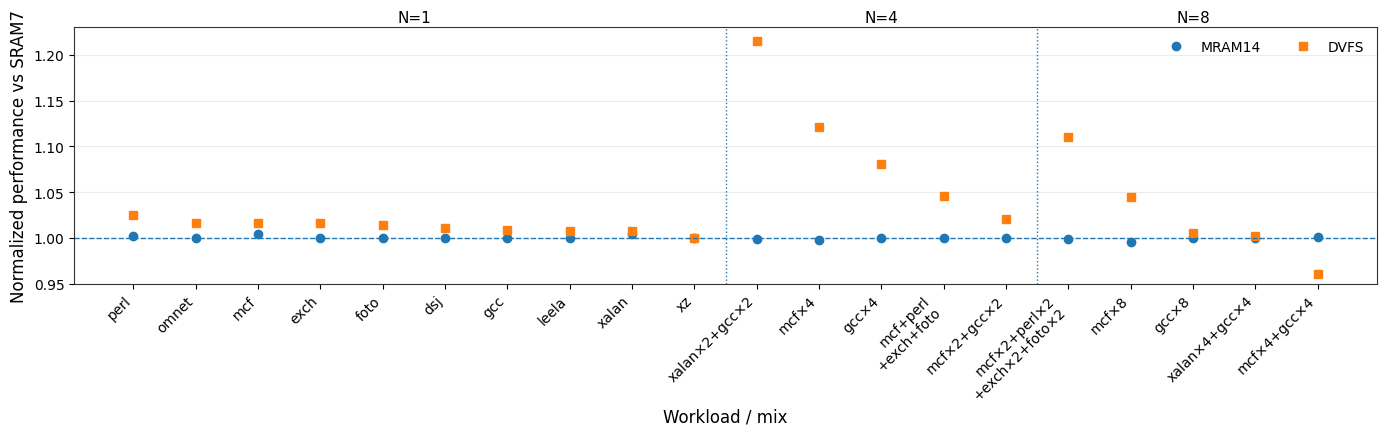

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import re

import csv
import os

CSV_PATH = os.path.expanduser("~/COSC_498/miniMXE/repro/agg/dvfs.csv")

label_map = {
    ("500.perlbench_r", "n1"): "perl",
    ("502.gcc_r", "n1"): "gcc",
    ("505.mcf_r", "n1"): "mcf",
    ("520.omnetpp_r", "n1"): "omnetpp",
    ("523.xalancbmk_r", "n1"): "xalan",
    ("531.deepsjeng_r", "n1"): "dsj",
    ("541.leela_r", "n1"): "leela",
    ("557.xz_r", "n1"): "xz",
    ("648.exchange2_s", "n1"): "exch",
    ("649.fotonik3d_s", "n1"): "foto",

    ("502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r", "n4"): "gcc×4",
    ("505.mcf_r+500.perlbench_r+648.exchange2_s+649.fotonik3d_s", "n4"): "mcf+perl+exch+foto",
    ("505.mcf_r+505.mcf_r+502.gcc_r+502.gcc_r", "n4"): "mcf×2+gcc×2",
    ("505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r", "n4"): "mcf×4",
    ("523.xalancbmk_r+523.xalancbmk_r+502.gcc_r+502.gcc_r", "n4"): "xalan×2+gcc×2",

    ("502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r", "n8"): "gcc×8",
    ("505.mcf_r+505.mcf_r+500.perlbench_r+500.perlbench_r+648.exchange2_s+648.exchange2_s+649.fotonik3d_s+649.fotonik3d_s", "n8"): "mcf×2+perl×2+exch×2+foto×2",
    ("505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r", "n8"): "mcf×4+gcc×4",
    ("505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r", "n8"): "mcf×8",
    ("523.xalancbmk_r+523.xalancbmk_r+523.xalancbmk_r+523.xalancbmk_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r", "n8"): "xalan×4+gcc×4",
}

data = []

with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["size_mb"] != "16":
            continue

        key = (row["workload"], row["n_tag"])
        if key not in label_map:
            continue

        label = label_map[key]

        if row["n_tag"] == "n1":
            dvfs = float(row["speedup_vs_sram7_ratio"])
            mram = dvfs / float(row["speedup_vs_mram14_ratio"])
        else:
            dvfs = float(row["wsn_vs_sram7"])
            mram = float(row["wsn_vs_mram14"]) / dvfs

        data.append((label, round(dvfs, 4), 1.0000, round(mram, 4)))

df = pd.DataFrame(data, columns=["Workload", "DVFS", "SRAM7", "MRAM14"])

def total_n(workload: str) -> int:
    total = 0
    for token in workload.split("+"):
        m = re.search(r"×(\d+)", token)
        total += int(m.group(1)) if m else 1
    return total

def shorten_label(label: str) -> str:
    return label.replace("omnetpp", "omnet")

def smart_multiline_label(label: str, max_parts_per_line=2):
    parts = shorten_label(label).split("+")
    lines = []
    for i in range(0, len(parts), max_parts_per_line):
        chunk = parts[i:i + max_parts_per_line]
        line = "+".join(chunk)
        if i > 0:
            line = "+" + line
        lines.append(line)
    return "\n".join(lines)

df["N"] = df["Workload"].apply(total_n)
df["MRAM14_rel"] = df["MRAM14"] / df["SRAM7"]
df["DVFS_rel"] = df["DVFS"] / df["SRAM7"]
df["Label"] = df["Workload"].apply(smart_multiline_label)

# sort within each regime by DVFS, then concatenate regimes in order
groups = []
boundaries = []
cursor = 0

for n in [1, 4, 8]:
    g = (
        df[df["N"] == n]
        .sort_values("DVFS_rel", ascending=False)
        .reset_index(drop=True)
    )
    groups.append(g)
    cursor += len(g)
    boundaries.append(cursor - 0.5)

plot_df = pd.concat(groups, ignore_index=True)

x = list(range(len(plot_df)))

y_min = min(plot_df["MRAM14_rel"].min(), plot_df["DVFS_rel"].min())
y_max = max(plot_df["MRAM14_rel"].max(), plot_df["DVFS_rel"].max())
ylim = (min(0.95, y_min - 0.01), y_max + 0.015)

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(x, plot_df["MRAM14_rel"], "o", label="MRAM14")
ax.plot(x, plot_df["DVFS_rel"], "s", label="DVFS")
ax.axhline(1.0, linestyle="--", linewidth=1)

# regime separators between N=1|4 and N=4|8
for boundary in boundaries[:-1]:
    ax.axvline(boundary, linestyle=":", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Label"], rotation=45, ha="right")
ax.set_ylim(*ylim)
ax.set_ylabel("Normalized performance vs SRAM7")
ax.set_xlabel("Workload / mix")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2, loc="upper right")

# optional regime labels above groups
group_sizes = [len(g) for g in groups]
starts = [0, group_sizes[0], group_sizes[0] + group_sizes[1]]
centers = [
    starts[0] + (group_sizes[0] - 1) / 2,
    starts[1] + (group_sizes[1] - 1) / 2,
    starts[2] + (group_sizes[2] - 1) / 2,
]
for center, label in zip(centers, ["N=1", "N=4", "N=8"]):
    ax.text(center, 1.01, label, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom")

plt.tight_layout()
plt.savefig("workload_one_figure_grouped.png", dpi=240)
plt.show()

## tab:outlier-cases

In [56]:
#!/usr/bin/env python3
import csv
import os

CSV_PATH = os.path.expanduser("~/COSC_498/miniMXE/repro/agg/dvfs.csv")

LEFT_WORKLOAD  = "523.xalancbmk_r+523.xalancbmk_r+502.gcc_r+502.gcc_r"   # xalan×2 + gcc×2
RIGHT_WORKLOAD = "505.mcf_r+505.mcf_r+505.mcf_r+505.mcf_r+502.gcc_r+502.gcc_r+502.gcc_r+502.gcc_r"  # mcf×4 + gcc×4
SIZE_MB = 16

LEFT_TITLE = "xalan×2 + gcc×2"
RIGHT_TITLE = "mcf×4 + gcc×4"


def parse_vec(s):
    if not s:
        return []
    return [float(x) for x in s.split("|") if x.strip()]


def load_row(workload, size_mb):
    with open(CSV_PATH, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if (
                row["workload"] == workload
                and row["size_mb"] == str(size_mb)
            ):
                return row
    raise RuntimeError(f"Row not found for workload={workload}, size_mb={size_mb}")


def fmt(v):
    return "–" if v is None else f"{v:.5f}"


def pad_list(xs, n):
    return xs + [None] * (n - len(xs))


left = load_row(LEFT_WORKLOAD, SIZE_MB)
right = load_row(RIGHT_WORKLOAD, SIZE_MB)

left_sram = parse_vec(left["sram7_times_s"])
left_dvfs = parse_vec(left["dvfs_times_s"])
right_sram = parse_vec(right["sram7_times_s"])
right_dvfs = parse_vec(right["dvfs_times_s"])

nrows = max(len(left_sram), len(left_dvfs), len(right_sram), len(right_dvfs))

left_sram = pad_list(left_sram, nrows)
left_dvfs = pad_list(left_dvfs, nrows)
right_sram = pad_list(right_sram, nrows)
right_dvfs = pad_list(right_dvfs, nrows)

# column widths
w_core = len("Core / Metric")
w_num = 8
gap = "  "

# total widths of grouped sections
group_w = w_num + len(gap) + w_num

# top rule
total_w = w_core + len(gap) + group_w + len(gap) + group_w
print("=" * total_w)

# title row
print(
    f"{'Core / Metric':<{w_core}}{gap}"
    f"{LEFT_TITLE:^{group_w}}{gap}"
    f"{RIGHT_TITLE:^{group_w}}"
)

# subgroup row
print(
    f"{'':<{w_core}}{gap}"
    f"{'SRAM7':>{w_num}}{gap}{'DVFS':>{w_num}}{gap}"
    f"{'SRAM7':>{w_num}}{gap}{'DVFS':>{w_num}}"
)

print("-" * total_w)

for i in range(nrows):
    print(
        f"{f'Core {i}':<{w_core}}{gap}"
        f"{fmt(left_sram[i]):>{w_num}}{gap}"
        f"{fmt(left_dvfs[i]):>{w_num}}{gap}"
        f"{fmt(right_sram[i]):>{w_num}}{gap}"
        f"{fmt(right_dvfs[i]):>{w_num}}"
    )

print("=" * total_w)

Core / Metric   xalan×2 + gcc×2      mcf×4 + gcc×4   
                  SRAM7      DVFS     SRAM7      DVFS
-----------------------------------------------------
Core 0          0.05527   0.08007   0.03877   0.02778
Core 1          0.05527   0.08081   0.03881   0.02792
Core 2          0.08592   0.04933   0.04166   0.03887
Core 3          0.08592   0.04928   0.04166   0.03888
Core 4                –         –   0.01954   0.03608
Core 5                –         –   0.01925   0.03672
Core 6                –         –   0.01983   0.02370
Core 7                –         –   0.02027   0.02370


# Extra plots

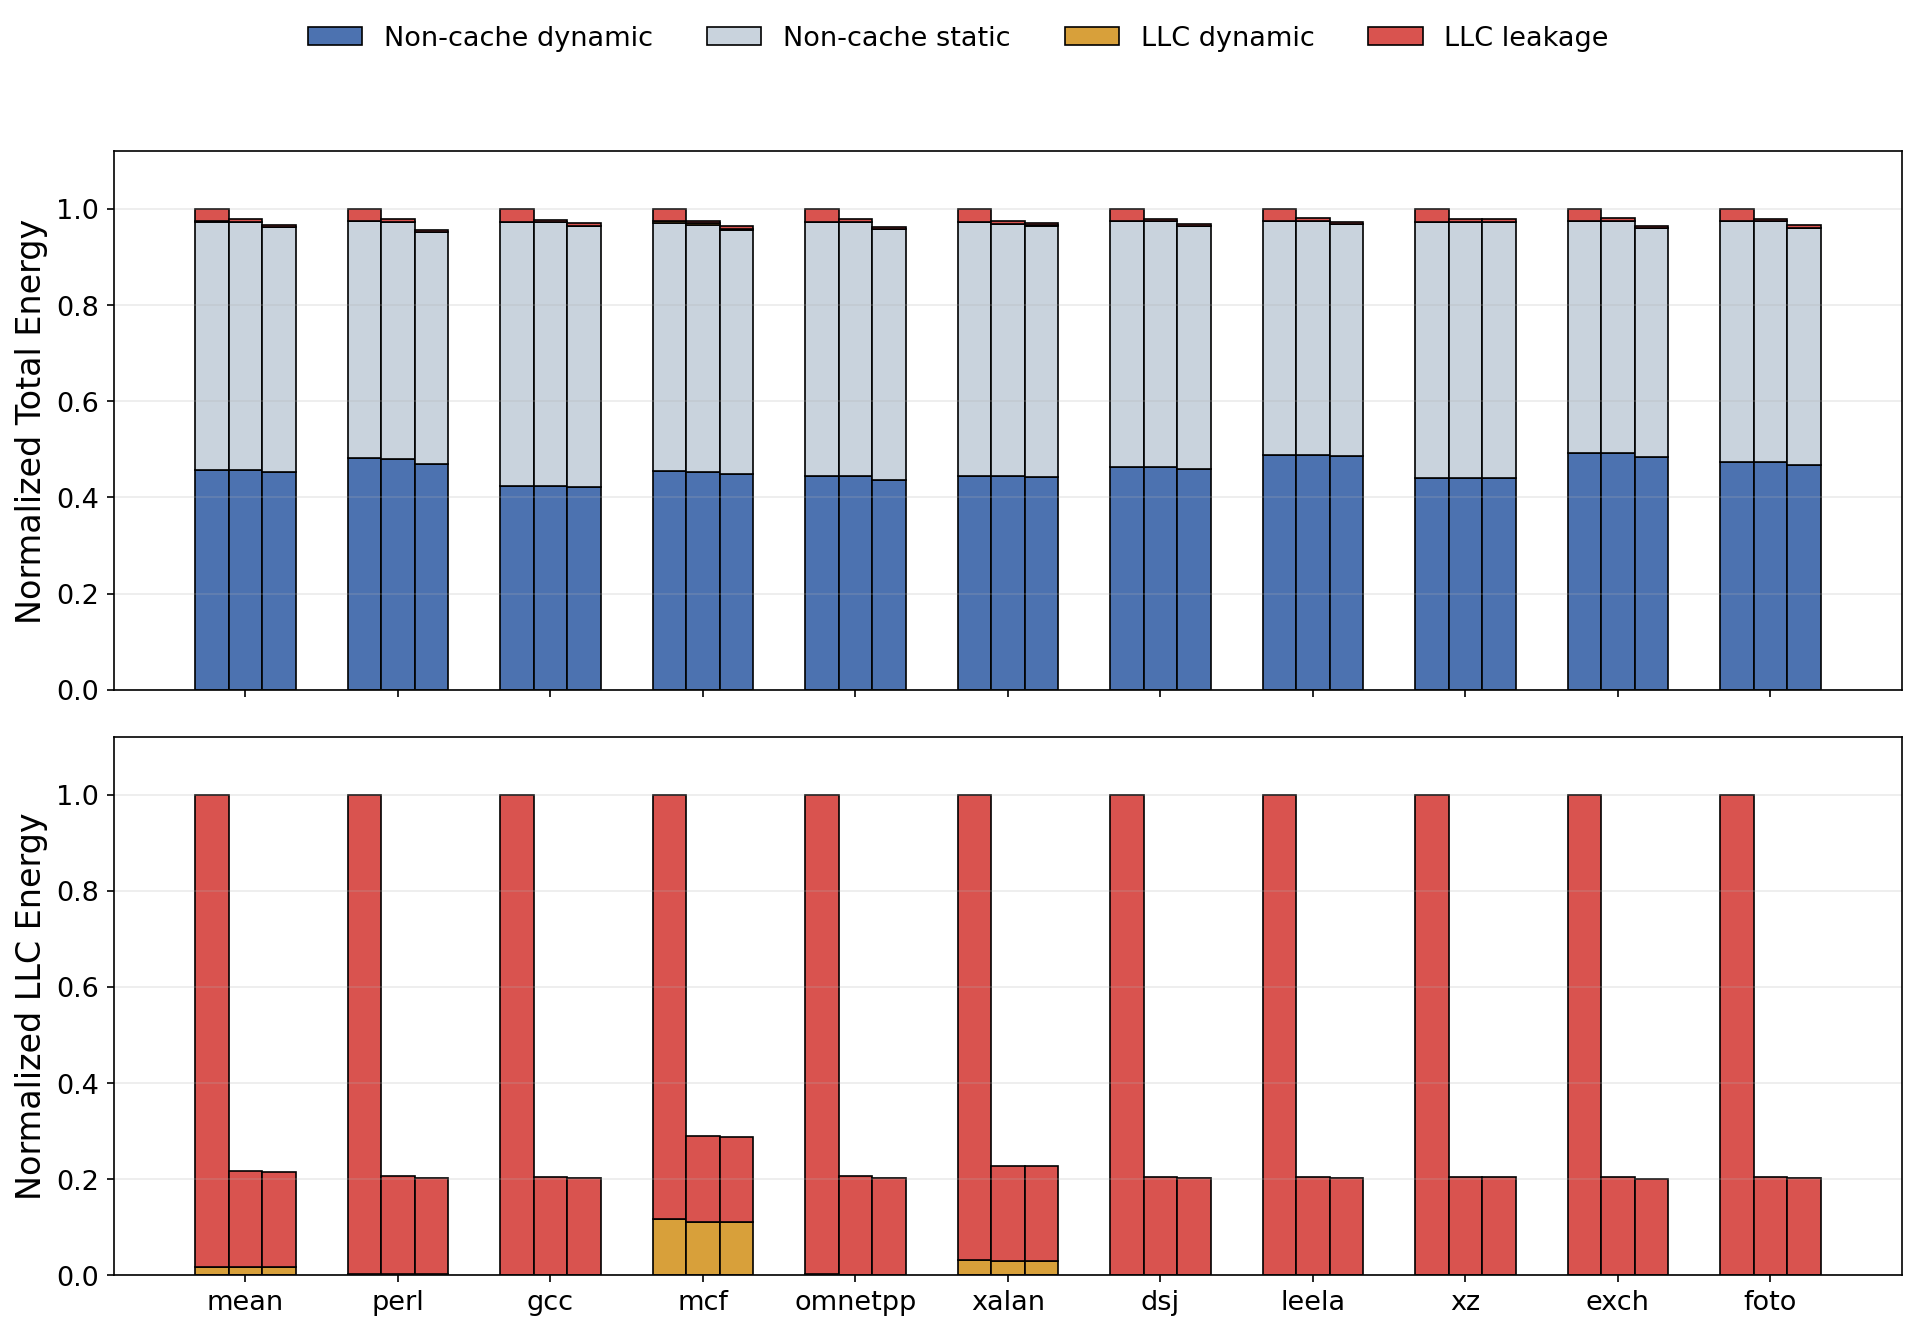


=== Energy decomposition raw values (J) ===

[SRAM7]
  bench  E_nc_dyn  E_nc_static  E_llc_dyn  E_llc_leak   E_total
   mean  3.811755     4.299166   0.003983    0.214145  8.329049
   perl  3.687667     3.787814   0.000597    0.188674  7.664753
    gcc  4.926287     6.369966   0.000209    0.317293 11.613755
    mcf  4.089653     4.631946   0.030738    0.230721  8.983057
omnetpp  4.477505     5.348788   0.000519    0.266427 10.093240
  xalan  3.802828     4.505300   0.007617    0.224412  8.540158
    dsj  3.764283     4.155610   0.000037    0.206994  8.126924
  leela  3.345161     3.330383   0.000025    0.165889  6.841458
     xz  3.161281     3.833452   0.000081    0.190947  7.185761
   exch  3.278224     3.223783   0.000000    0.160579  6.662586
   foto  3.584658     3.804618   0.000007    0.189511  7.578794

[MRAM14]
  bench  E_nc_dyn  E_nc_static  E_llc_dyn  E_llc_leak   E_total
   mean  3.808006     4.294895   0.003754    0.043805  8.150460
   perl  3.681618     3.781601   0.00056

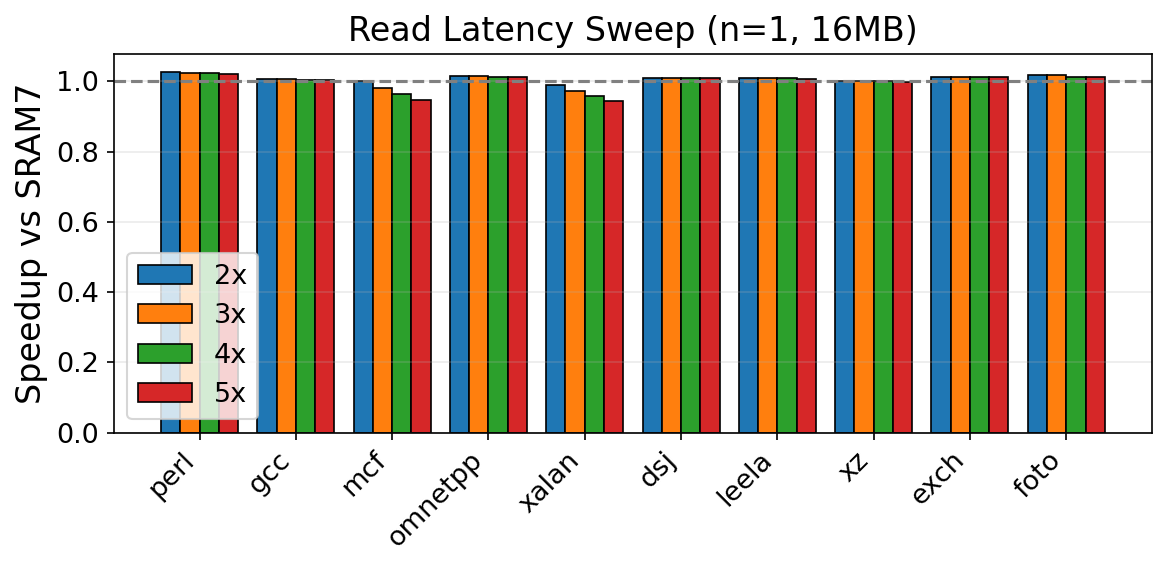


=== Read latency raw values (ratio = 1 + speedup/100) ===
  bench  x2_speedup_pct  x2_ratio  x3_speedup_pct  x3_ratio  x4_speedup_pct  x4_ratio  x5_speedup_pct  x5_ratio
   perl        2.783306  1.027833        2.498755  1.024988        2.414058  1.024141        1.956997  1.019570
    gcc        0.613101  1.006131        0.538263  1.005383        0.476518  1.004765        0.436753  1.004368
    mcf        0.054580  1.000546       -1.811877  0.981881       -3.492180  0.965078       -5.319234  0.946808
omnetpp        1.434491  1.014345        1.376778  1.013768        1.263512  1.012635        1.255044  1.012550
  xalan       -1.160144  0.988399       -2.881318  0.971187       -4.146290  0.958537       -5.568136  0.944319
    dsj        1.073311  1.010733        1.026881  1.010269        1.049129  1.010491        0.995476  1.009955
  leela        1.068758  1.010688        1.014773  1.010148        0.955149  1.009551        0.791281  1.007913
     xz       -0.011824  0.999882       -0.04

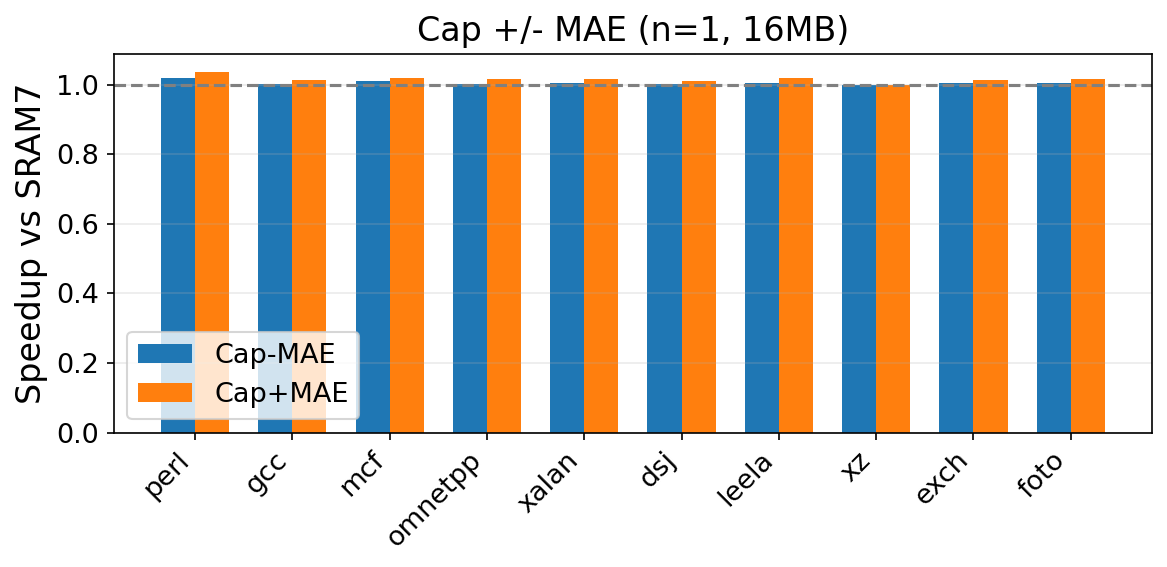


=== Cap +/- MAE raw values (ratio = 1 + speedup/100) ===
  bench  cap_minus_speedup_pct  cap_minus_ratio  cap_plus_speedup_pct  cap_plus_ratio
   perl               1.841787         1.018418              3.772700        1.037727
    gcc               0.099897         1.000999              1.291211        1.012912
    mcf               1.127268         1.011273              1.967899        1.019679
omnetpp               0.246792         1.002468              1.577919        1.015779
  xalan               0.470297         1.004703              1.669841        1.016698
    dsj               0.084127         1.000841              1.188161        1.011882
  leela               0.545328         1.005453              2.017680        1.020177
     xz               0.025581         1.000256              0.025581        1.000256
   exch               0.477163         1.004772              1.382043        1.013820
   foto               0.427796         1.004278              1.680956        1.016

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "~/COSC_498/miniMXE/repro/agg/extra.csv"
df = pd.read_csv(csv_path)

name_map = {
    "perlbench": "perl",
    "gcc": "gcc",
    "mcf": "mcf",
    "omnetpp": "omnetpp",
    "xalancbmk": "xalan",
    "deepsjeng": "dsj",
    "leela": "leela",
    "xz": "xz",
    "exchange2": "exch",
    "fotonik3d": "foto",
}
df["bench_short"] = df["bench_short"].replace(name_map)

bench_order = ["perl", "gcc", "mcf", "omnetpp", "xalan", "dsj", "leela", "xz", "exch", "foto"]
xtick_labels = ["mean"] + bench_order

# -----------------------------
# Plot 1: Energy decomposition
# -----------------------------
e = df[df["table_group"] == "table8_energy"].copy()

cfg_map = {"SRAM7": "SRAM7", "MRAM14": "MRAM14", "M+DVFS": "M+DVFS"}
configs = ["SRAM7", "MRAM14", "M+DVFS"]

raw = {cfg: {} for cfg in configs}

for cfg in configs:
    sub = e[e["variant"] == cfg].copy()
    for b in bench_order:
        r = sub[sub["bench_short"] == b]
        if len(r) == 0:
            continue
        r = r.iloc[0]
        raw[cfg][b] = [
            float(r["e_nc_dyn_j"]),
            float(r["e_nc_static_j"]),
            float(r["e_llc_dyn_j"]),
            float(r["e_llc_leak_j"]),
        ]

for cfg in configs:
    arr = np.array([raw[cfg][b] for b in bench_order], dtype=float)
    raw[cfg] = {"mean": arr.mean(axis=0), **raw[cfg]}

plot_order = ["mean"] + bench_order
vals = {cfg: np.array([raw[cfg][b] for b in plot_order], dtype=float) for cfg in configs}

baseline_total = vals["SRAM7"].sum(axis=1)
baseline_llc = vals["SRAM7"][:, 2] + vals["SRAM7"][:, 3]

norm_total = {}
norm_llc = {}
for cfg in configs:
    arr = vals[cfg]
    norm_total[cfg] = np.column_stack([
        arr[:, 0] / baseline_total,
        arr[:, 1] / baseline_total,
        arr[:, 2] / baseline_total,
        arr[:, 3] / baseline_total,
    ])
    norm_llc[cfg] = np.column_stack([
        np.zeros(len(plot_order)),
        np.zeros(len(plot_order)),
        np.divide(arr[:, 2], baseline_llc, out=np.zeros(len(plot_order)), where=baseline_llc > 0),
        np.divide(arr[:, 3], baseline_llc, out=np.zeros(len(plot_order)), where=baseline_llc > 0),
    ])

x = np.arange(len(plot_order))
w = 0.22
offsets = [-w, 0, w]

c_nc_dyn = "#4C72B0"
c_nc_static = "#C9D3DD"
c_llc_dyn = "#D8A03A"
c_llc_leak = "#D9534F"

# Bigger fonts everywhere
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

fig, axes = plt.subplots(2, 1, figsize=(13, 8.8), sharex=True)

ax = axes[0]
for i, cfg in enumerate(configs):
    xpos = x + offsets[i]
    arr = norm_total[cfg]
    ax.bar(xpos, arr[:, 0], width=w, color=c_nc_dyn, label="Non-cache dynamic" if i == 0 else None, edgecolor="black", linewidth=0.8)
    ax.bar(xpos, arr[:, 1], width=w, bottom=arr[:, 0], color=c_nc_static, label="Non-cache static" if i == 0 else None, edgecolor="black", linewidth=0.8)
    ax.bar(xpos, arr[:, 2], width=w, bottom=arr[:, 0] + arr[:, 1], color=c_llc_dyn, label="LLC dynamic" if i == 0 else None, edgecolor="black", linewidth=0.8)
    ax.bar(xpos, arr[:, 3], width=w, bottom=arr[:, 0] + arr[:, 1] + arr[:, 2], color=c_llc_leak, label="LLC leakage" if i == 0 else None, edgecolor="black", linewidth=0.8)

ax.set_ylabel("Normalized Total Energy")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", alpha=0.25)

ax2 = axes[1]
for i, cfg in enumerate(configs):
    xpos = x + offsets[i]
    arr = norm_llc[cfg]
    ax2.bar(xpos, arr[:, 2], width=w, color=c_llc_dyn, label="LLC dynamic" if i == 0 else None, edgecolor="black", linewidth=0.8)
    ax2.bar(xpos, arr[:, 3], width=w, bottom=arr[:, 2], color=c_llc_leak, label="LLC leakage" if i == 0 else None, edgecolor="black", linewidth=0.8)

ax2.set_ylabel("Normalized LLC Energy")
ax2.set_ylim(0, 1.12)
ax2.grid(axis="y", alpha=0.25)
ax2.set_xticks(x)
ax2.set_xticklabels(xtick_labels)

# Legend above the whole figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    frameon=False
)

# Leave room for the top legend
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print("\n=== Energy decomposition raw values (J) ===")
for cfg in configs:
    print(f"\n[{cfg}]")
    rows = []
    for b in plot_order:
        v = raw[cfg][b]
        rows.append([b, v[0], v[1], v[2], v[3], sum(v)])
    out = pd.DataFrame(
        rows,
        columns=["bench", "E_nc_dyn", "E_nc_static", "E_llc_dyn", "E_llc_leak", "E_total"]
    )
    print(out.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n=== Energy decomposition normalized values ===")
for cfg in configs:
    print(f"\n[{cfg}] total-energy normalized")
    out1 = pd.DataFrame(
        norm_total[cfg],
        columns=["nc_dyn_norm", "nc_static_norm", "llc_dyn_norm", "llc_leak_norm"]
    )
    out1.insert(0, "bench", plot_order)
    print(out1.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

    print(f"\n[{cfg}] LLC-only normalized")
    out2 = pd.DataFrame(
        norm_llc[cfg][:, 2:4],
        columns=["llc_dyn_norm", "llc_leak_norm"]
    )
    out2.insert(0, "bench", plot_order)
    print(out2.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    
# -----------------------------
# Plot 2: Read latency sweep
# -----------------------------
r = df[df["table_group"] == "table10_readlat"].copy()
r = r[(r["variant"] == "M+DVFS") & (r["n_tag"] == "n1")].copy()
r["sweep_value"] = pd.to_numeric(r["sweep_value"], errors="coerce")

lat_mults = [2, 3, 4, 5]

x = np.arange(len(bench_order))
n_bars = len(lat_mults)
w = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(8, 4))

for bi, mult in enumerate(lat_mults):
    vals = []
    for b in bench_order:
        rr = r[(r["bench_short"] == b) & (r["sweep_value"] == float(mult))]
        if len(rr) == 0:
            vals.append(np.nan)
        else:
            vals.append(1.0 + float(rr.iloc[0]["speedup_pct_vs_sram7"]) / 100.0)

    ax.bar(
        x + (bi - (n_bars - 1) / 2.0) * w,
        vals,
        w,
        label=f"{mult}x",
        edgecolor="black",
        linewidth=0.8,
    )

ax.axhline(1.0, color="gray", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(bench_order, rotation=45, ha="right")
ax.set_ylabel("Speedup vs SRAM7")
ax.set_title("Read Latency Sweep (n=1, 16MB)")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== Read latency raw values (ratio = 1 + speedup/100) ===")
rl_rows = []
for b in bench_order:
    row = {"bench": b}
    for mult in lat_mults:
        rr = r[(r["bench_short"] == b) & (r["sweep_value"] == float(mult))]
        row[f"x{mult}_speedup_pct"] = float(rr.iloc[0]["speedup_pct_vs_sram7"]) if len(rr) else np.nan
        row[f"x{mult}_ratio"] = 1.0 + row[f"x{mult}_speedup_pct"] / 100.0 if len(rr) else np.nan
    rl_rows.append(row)

rl_df = pd.DataFrame(rl_rows)
print(rl_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


# -----------------------------
# Plot 3: Cap +/- MAE
# -----------------------------
c = df[df["table_group"] == "table12_cap_mae"].copy()
c = c[c["n_tag"] == "n1"].copy()

x = np.arange(len(bench_order))
w = 0.35

minus_vals = []
plus_vals = []

for b in bench_order:
    rm = c[(c["bench_short"] == b) & (c["variant"] == "cap_minus_mae")]
    rp = c[(c["bench_short"] == b) & (c["variant"] == "cap_plus_mae")]

    minus_vals.append(1.0 + float(rm.iloc[0]["speedup_pct_vs_sram7"]) / 100.0 if len(rm) else np.nan)
    plus_vals.append(1.0 + float(rp.iloc[0]["speedup_pct_vs_sram7"]) / 100.0 if len(rp) else np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, minus_vals, w, label="Cap-MAE")
ax.bar(x + w/2, plus_vals,  w, label="Cap+MAE")

ax.axhline(1.0, color="gray", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(bench_order, rotation=45, ha="right")
ax.set_ylabel("Speedup vs SRAM7")
ax.set_title("Cap +/- MAE (n=1, 16MB)")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== Cap +/- MAE raw values (ratio = 1 + speedup/100) ===")
cap_rows = []
for b, mv, pv in zip(bench_order, minus_vals, plus_vals):
    rm = c[(c["bench_short"] == b) & (c["variant"] == "cap_minus_mae")]
    rp = c[(c["bench_short"] == b) & (c["variant"] == "cap_plus_mae")]

    m_pct = float(rm.iloc[0]["speedup_pct_vs_sram7"]) if len(rm) else np.nan
    p_pct = float(rp.iloc[0]["speedup_pct_vs_sram7"]) if len(rp) else np.nan

    cap_rows.append({
        "bench": b,
        "cap_minus_speedup_pct": m_pct,
        "cap_minus_ratio": mv,
        "cap_plus_speedup_pct": p_pct,
        "cap_plus_ratio": pv,
    })

cap_df = pd.DataFrame(cap_rows)
print(cap_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))